<a href="https://colab.research.google.com/github/isocan/ML-accelerated-ORR/blob/main/notebooks/04_stageIII_vasp_gibbs_overpotential_pt_ranking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

# Stage III — VASP/VaspGibbs/VASPsol ORR thermodynamics and Pt(111) ranking

This notebook completes the public multi-fidelity ORR workflow after the Stage I
EqV2 and Stage II eSEN/OC25 and AQCat25 relaxation notebooks. It demonstrates,
for one representative candidate, how final VASP outputs are converted into:

- vacuum and implicit-solvent adsorption Gibbs free energies for O*, OH*, and OOH*;
- the four ORR step potentials, limiting potential, and potential-determining step (PDS);
- the ORR overpotential and comparison with the corresponding Pt(111) benchmark;
- static, manuscript-ready structure and free-energy figures.

```python
SURFACE_ID = "mp-10260_111"
```

The full study applies the same post-processing to all validated candidates. The
repository includes only one compact raw-output demonstration, because the full
VASP output archive is substantially larger.

## Public-data scope

The demonstration retains the complete relaxed `CONTCAR` structures selected
for the manuscript example. A small fixture writer materializes parser-ready
`OUTCAR` and `VaspGibbs.md` excerpts containing the final electronic energies
and thermal corrections used in the worked calculation. Licensed VASP `POTCAR`
files and the full production outputs are not redistributed.


## 1. One fixed repository layout

```text
data/stageIII_demo/
├── Molecules/
│   ├── H2/{Freq/OUTCAR, Freq/VaspGibbs.md, Sol/OUTCAR}
│   └── H2O/{Freq/OUTCAR, Freq/VaspGibbs.md, Sol/OUTCAR}
└── mp-10260_111/
    ├── bare/{CONTCAR, OUTCAR, Freq/VaspGibbs.md, Sol/OUTCAR}
    ├── O/{CONTCAR, OUTCAR, Freq/VaspGibbs.md, Sol/OUTCAR}
    ├── OH/{CONTCAR, OUTCAR, Freq/VaspGibbs.md, Sol/OUTCAR}
    └── OOH/{CONTCAR, OUTCAR, Freq/VaspGibbs.md, Sol/OUTCAR}
```

`Freq/VaspGibbs.md` supplies the thermal/vibrational correction
$G-E_{\mathrm{DFT}}$. `Sol/OUTCAR` supplies the implicit-solvent electronic
response. H₂ and H₂O remain the gas-phase computational-hydrogen-electrode
references in both environments.


In [1]:
from pathlib import Path
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    REPO_ROOT = Path("/content/ML-accelerated-ORR")
    if not REPO_ROOT.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/isocan/ML-accelerated-ORR.git", str(REPO_ROOT)],
            check=True,
        )
else:
    current = Path.cwd().resolve()
    REPO_ROOT = current.parent if current.name == "notebooks" else current

sys.path.insert(0, str(REPO_ROOT / "src"))

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from stageIII_demo_fixture import materialize_stageIII_demo
from stageIII_orr_gibbs import (
    plot_adsorption_decomposition,
    plot_intermediate_structures,
    plot_orr_free_energy,
    plot_pt_comparison,
    run_workflow,
    validate_layout,
    verify_demo_results,
)

SURFACE_ID = "mp-10260_111"
DATA_ROOT = REPO_ROOT / "data" / "stageIII_demo"
OUTPUT_DIR = REPO_ROOT / "outputs" / "stageIII_demo"
materialize_stageIII_demo(DATA_ROOT)

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 8,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

print("Runtime:", "Google Colab" if IN_COLAB else "local/GitHub Actions")
print("Demo data: data/stageIII_demo")


Runtime: Google Colab
Demo data: data/stageIII_demo


/content/ML-accelerated-ORR/src/stageIII_orr_gibbs.py:329: SyntaxWarning: invalid escape sequence '\D'
  ax.annotate(f"PDS: {row['PDS']}\n$\Delta G_{{PDS}}$ = {step_dg:.3f} eV", xy=(pds_index + 0.5, (levels[pds_index] + levels[pds_index + 1]) / 2), xytext=(0, 18), textcoords="offset points", ha="center", fontsize=7.2, color="#B2182B", arrowprops=dict(arrowstyle="-", color="#B2182B", lw=0.8))
/content/ML-accelerated-ORR/src/stageIII_orr_gibbs.py:332: SyntaxWarning: invalid escape sequence '\e'
  ax.set_title(f"{row['slab']} — {row['environment']}\n$U_L$={row['U_L_ORR_V']:.3f} V, $\eta_{{ORR}}$={row['eta_ORR_V']:.3f} V", fontsize=8.5)


## 2. Validate the public demonstration and inspect provenance

In [2]:
surfaces = validate_layout(DATA_ROOT)
assert [surface.name for surface in surfaces] == [SURFACE_ID]

manifest = pd.read_csv(DATA_ROOT / "source_manifest.csv")
display(manifest)


,state,structure,adsorbate_coordinates
0,bare,data/stageIII_structures/mp-10260_111_bare.CON...,none
1,O,data/stageIII_structures/mp-10260_111_bare.CON...,O
2,OH,data/stageIII_structures/mp-10260_111_bare.CON...,OH
3,OOH,data/stageIII_structures/mp-10260_111_bare.CON...,OOH


## 3. Representative VASP settings

The public settings correspond to RPBE-D3 slab calculations, finite-difference
frequencies, and VASPsol implicit water. The notebook does not redistribute
licensed PAW datasets. For the manuscript and Supporting Information, report the
functional, dispersion correction, cutoff, k-point mesh, dipole correction,
frequency displacement, and dielectric constant together with the structural
models.


In [3]:
def parse_incar(path):
    rows = []
    for line in path.read_text().splitlines():
        clean = line.split("#", 1)[0].strip()
        if "=" in clean:
            key, value = [part.strip() for part in clean.split("=", 1)]
            rows.append({"setting": key, "value": value, "file": path.name})
    return rows

settings_dir = DATA_ROOT / "calculation_settings"
settings = pd.DataFrame(
    parse_incar(settings_dir / "INCAR_vacuum_relax")
    + parse_incar(settings_dir / "INCAR_frequency")
    + parse_incar(settings_dir / "INCAR_implicit_solvent")
)
key_tags = ["GGA", "IVDW", "ENCUT", "ISPIN", "LDIPOL", "IDIPOL", "IBRION", "NFREE", "POTIM", "LSOL", "EB_K"]
display(settings[settings["setting"].isin(key_tags)].drop_duplicates().reset_index(drop=True))
print((settings_dir / "KPOINTS").read_text())


,setting,value,file
0,GGA,RP,INCAR_vacuum_relax
1,IVDW,12,INCAR_vacuum_relax
2,ENCUT,500,INCAR_vacuum_relax
3,ISPIN,1,INCAR_vacuum_relax
4,LDIPOL,.TRUE.,INCAR_vacuum_relax
5,IDIPOL,3,INCAR_vacuum_relax
6,GGA,RP,INCAR_frequency
7,IVDW,12,INCAR_frequency
8,ENCUT,500,INCAR_frequency
9,IBRION,5,INCAR_frequency


Automatic mesh
0
Gamma
4 4 1
0 0 0



## 4. Relaxed bare surface and adsorbed ORR intermediates

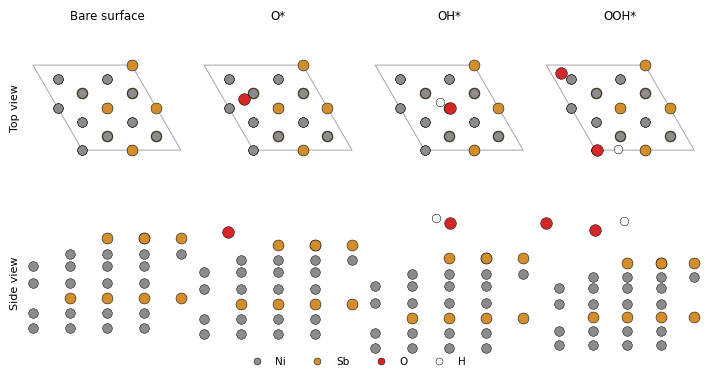

In [4]:
structure_figure = plot_intermediate_structures(
    DATA_ROOT / SURFACE_ID,
    OUTPUT_DIR / "figures" / f"Figure_stageIII_intermediates_{SURFACE_ID}",
)
display(structure_figure)
plt.close(structure_figure)


## 5. Thermodynamic definitions

The final VASP electronic energy is read from `energy(sigma->0)`. For each state,

$$G_{\mathrm{vac}} = E_{\mathrm{vac}} + (G-E_{\mathrm{DFT}})_{\mathrm{VaspGibbs}}.$$

The CHE references are

$$G_{\mathrm{ref}}(\mathrm O^*)=G_{\mathrm{H_2O}}-G_{\mathrm{H_2}},$$
$$G_{\mathrm{ref}}(\mathrm{OH}^*)=G_{\mathrm{H_2O}}-\tfrac12G_{\mathrm{H_2}},$$
$$G_{\mathrm{ref}}(\mathrm{OOH}^*)=2G_{\mathrm{H_2O}}-\tfrac32G_{\mathrm{H_2}}.$$

The implicit-solvent contribution is evaluated by subtracting the solvent
response of the bare slab:

$$\Delta G_{\mathrm{solv}}(X^*)=
[E_{\mathrm{sol}}(X^*)-E_{\mathrm{vac}}(X^*)]-
[E_{\mathrm{sol}}(*)-E_{\mathrm{vac}}(*)].$$

Therefore,

$$\Delta G_{\mathrm{sol}}=\Delta E_{\mathrm{vac}}+
\Delta G_{\mathrm{vib}}+\Delta G_{\mathrm{solv}}.$$


In [5]:
outputs = run_workflow(DATA_ROOT, OUTPUT_DIR)
state_energies = outputs["state_energies"]
molecular_references = outputs["molecular_references"]
adsorption = outputs["adsorption_free_energies"]
orr_results = outputs["orr_results"]
pt_ranking = outputs["pt_ranking"]
verify_demo_results(orr_results)
print("Numerical regression check passed.")


Numerical regression check passed.


## 6. Extracted electronic energies and VaspGibbs corrections

In [6]:
display(
    state_energies[[
        "slab", "species", "state_type", "vacuum_energy_eV",
        "gibbs_correction_eV", "vacuum_gibbs_eV", "solvent_energy_eV",
        "electronic_solvation_shift_eV",
    ]].round(6)
)


,slab,species,state_type,vacuum_energy_eV,gibbs_correction_eV,vacuum_gibbs_eV,solvent_energy_eV,electronic_solvation_shift_eV
0,mp-10260_111,H2,gas_reference,-6.978456,-0.043692,-7.022148,-6.801696,0.176760
1,mp-10260_111,H2O,gas_reference,-14.175141,0.084076,-14.091065,-14.481140,-0.305999
2,mp-10260_111,bare,surface_state,-239.248371,-0.332134,-239.580505,-239.297784,-0.049413
3,mp-10260_111,O,surface_state,-244.751370,-0.326735,-245.078105,-244.876053,-0.124683
4,mp-10260_111,OH,surface_state,-249.203766,-0.126329,-249.330095,-249.419190,-0.215424
5,mp-10260_111,OOH,surface_state,-253.198086,-0.096206,-253.294292,-253.460653,-0.262568


## 7. H₂/H₂O CHE reference terms

In [7]:
display(molecular_references.round(6))

,adsorbate,reference_definition,electronic_reference_eV,reference_gibbs_correction_eV,gibbs_reference_eV
0,O,G(H2O)-G(H2),-7.196685,0.127768,-7.068917
1,OH,G(H2O)-0.5G(H2),-10.685913,0.105922,-10.579991
2,OOH,2G(H2O)-1.5G(H2),-17.882598,0.233690,-17.648908


## 8. Adsorption free-energy decomposition

,slab,adsorbate,DeltaE_vac_eV,DeltaG_vib_eV,DeltaG_solv_eV,DeltaG_vac_eV,DeltaG_sol_eV,closure_error_eV
0,mp-10260_111,O,1.693686,-0.122369,-0.075270,1.571317,1.496047,0.0
1,mp-10260_111,OH,0.730518,0.099883,-0.166011,0.830401,0.664390,0.0
2,mp-10260_111,OOH,3.932883,0.002239,-0.213155,3.935121,3.721967,0.0


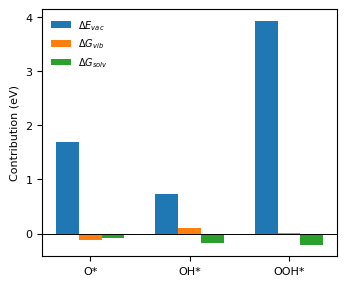

In [8]:
display(adsorption.round(6))
decomposition_figure = plot_adsorption_decomposition(
    adsorption,
    OUTPUT_DIR / "figures" / f"Figure_stageIII_decomposition_{SURFACE_ID}",
)
display(decomposition_figure)
plt.close(decomposition_figure)


## 9. ORR limiting potential, PDS, and overpotential

For the associative four-electron ORR pathway,

$$U_1=4.92-\Delta G_{\mathrm{OOH}},\qquad
U_2=\Delta G_{\mathrm{OOH}}-\Delta G_{\mathrm O},$$

$$U_3=\Delta G_{\mathrm O}-\Delta G_{\mathrm{OH}},\qquad
U_4=\Delta G_{\mathrm{OH}}.$$

The limiting potential and overpotential are

$$U_L=\min(U_1,U_2,U_3,U_4),\qquad
\eta_{\mathrm{ORR}}=1.23-U_L.$$

The step associated with the smallest $U_i$ is the PDS. In the free-energy
figures below, the landscape is shown at $U=1.23$ V; the uphill PDS height is
therefore equal to $\eta_{\mathrm{ORR}}$.


In [9]:
display(
    orr_results[[
        "slab", "environment", "G_O_eV", "G_OH_eV", "G_OOH_eV",
        "U1_O2_to_OOH_V", "U2_OOH_to_O_V", "U3_O_to_OH_V",
        "U4_OH_to_H2O_V", "U_L_ORR_V", "eta_ORR_V", "PDS",
    ]].round(4)
)


,slab,environment,G_O_eV,G_OH_eV,G_OOH_eV,U1_O2_to_OOH_V,U2_OOH_to_O_V,U3_O_to_OH_V,U4_OH_to_H2O_V,U_L_ORR_V,eta_ORR_V,PDS
0,mp-10260_111,vacuum,1.5713,0.8304,3.9351,0.9849,2.3638,0.7409,0.8304,0.7409,0.4891,O*→OH*
1,mp-10260_111,solvent,1.4960,0.6644,3.7220,1.1980,2.2259,0.8317,0.6644,0.6644,0.5656,OH*→H2O


### Vacuum Gibbs free-energy landscape

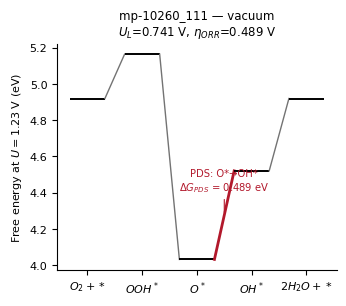

In [10]:
vacuum_row = orr_results.loc[orr_results["environment"].eq("vacuum")].iloc[0]
vacuum_figure = plot_orr_free_energy(
    vacuum_row,
    OUTPUT_DIR / "figures" / f"Figure_stageIII_ORR_vacuum_{SURFACE_ID}",
)
display(vacuum_figure)
plt.close(vacuum_figure)


### Implicit-solvent Gibbs free-energy landscape

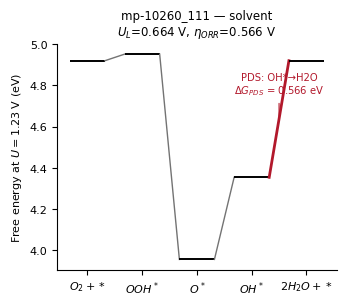

In [11]:
solvent_row = orr_results.loc[orr_results["environment"].eq("solvent")].iloc[0]
solvent_figure = plot_orr_free_energy(
    solvent_row,
    OUTPUT_DIR / "figures" / f"Figure_stageIII_ORR_solvent_{SURFACE_ID}",
)
display(solvent_figure)
plt.close(solvent_figure)


## 10. Pt(111)-referenced overpotential ranking

,environment,slab,eta_ORR_V,PDS,Pt111_eta_ORR_V,Pt111_PDS,delta_eta_vs_Pt111_V,better_than_Pt111
0,vacuum,mp-10260_111,0.4891,O*→OH*,0.824,O*→OH*,-0.3349,True
1,solvent,mp-10260_111,0.5656,OH*→H2O,0.832,O*→OH*,-0.2664,True


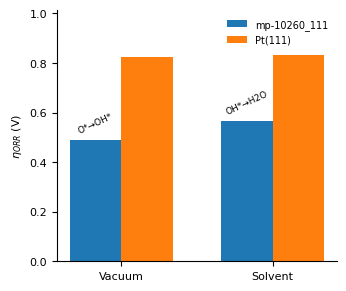

In [12]:
display(
    pt_ranking[[
        "environment", "slab", "eta_ORR_V", "PDS", "Pt111_eta_ORR_V",
        "Pt111_PDS", "delta_eta_vs_Pt111_V", "better_than_Pt111",
    ]].round(4)
)
comparison_figure = plot_pt_comparison(
    pt_ranking,
    OUTPUT_DIR / "figures" / "Figure_stageIII_overpotential_vs_Pt111",
)
display(comparison_figure)
plt.close(comparison_figure)


## 11. Reuse for the complete candidate set

To process additional candidates, add one folder per surface using the same
`bare/O/OH/OOH` layout. `run_workflow` discovers every `mp-*_*` folder,
calculates both environments, exports one canonical set of tables, and applies
the Pt(111) comparison without branch-specific adapters.

```python
from stageIII_orr_gibbs import run_workflow
run_workflow(Path("data/stageIII_complete"), Path("outputs/stageIII_complete"))
```

### Files exported by this notebook

- `state_energies.csv`
- `molecular_references.csv`
- `adsorption_free_energies.csv`
- `orr_results.csv`
- `pt_ranking.csv`
- PNG, PDF, and SVG publication figures
- `run_metadata.json`

The GitHub Actions workflow re-executes this notebook, runs numerical regression
tests, and uploads the executed notebook and generated tables/figures as a
workflow artifact.


In [13]:
print("Generated outputs:")
for path in sorted(OUTPUT_DIR.rglob("*")):
    if path.is_file():
        print(" -", path.relative_to(REPO_ROOT))


Generated outputs:
 - outputs/stageIII_demo/adsorption_free_energies.csv
 - outputs/stageIII_demo/figures/Figure_stageIII_ORR_solvent_mp-10260_111.pdf
 - outputs/stageIII_demo/figures/Figure_stageIII_ORR_solvent_mp-10260_111.png
 - outputs/stageIII_demo/figures/Figure_stageIII_ORR_solvent_mp-10260_111.svg
 - outputs/stageIII_demo/figures/Figure_stageIII_ORR_vacuum_mp-10260_111.pdf
 - outputs/stageIII_demo/figures/Figure_stageIII_ORR_vacuum_mp-10260_111.png
 - outputs/stageIII_demo/figures/Figure_stageIII_ORR_vacuum_mp-10260_111.svg
 - outputs/stageIII_demo/figures/Figure_stageIII_decomposition_mp-10260_111.pdf
 - outputs/stageIII_demo/figures/Figure_stageIII_decomposition_mp-10260_111.png
 - outputs/stageIII_demo/figures/Figure_stageIII_decomposition_mp-10260_111.svg
 - outputs/stageIII_demo/figures/Figure_stageIII_intermediates_mp-10260_111.pdf
 - outputs/stageIII_demo/figures/Figure_stageIII_intermediates_mp-10260_111.png
 - outputs/stageIII_demo/figures/Figure_stageIII_intermediates